# 🎗️ MedSynapse — Breast Cancer Biopsy Diagnostic System
### Multi-Model Machine Learning Benchmark on Wisconsin Diagnostic Breast Cancer (WDBC) Imaging Features

[![Dataset: WDBC](https://img.shields.io/badge/Dataset-Wisconsin%20Diagnostic%20Breast%20Cancer-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
[![Architecture: Ensemble ML](https://img.shields.io/badge/Architecture-Voting%20Classifier%20%7C%20SVM-green?style=for-the-badge&logo=scikit-learn)](https://scikit-learn.org)
[![Accuracy: 96.49%](https://img.shields.io/badge/Test%20Accuracy-96.49%25-brightgreen?style=for-the-badge)]()
[![Classes: 2 Pathological States](https://img.shields.io/badge/Classes-Malignant%20%7C%20Benign-orange?style=for-the-badge)]()
[![Platform: MedSynapse](https://img.shields.io/badge/Platform-MedSynapse%20AI-red?style=for-the-badge)]()

---

### 📋 Overview & Clinical Significance
Fine Needle Aspiration (FNA) cytology is a minimally invasive biopsy procedure used to assess breast lumps for malignancy. Digitized nuclear morphometry provides quantitative characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, fractal dimension). This clinical system analyzes 30 nuclear morphometric descriptors to distinguish malignant neoplasia from benign changes:

| Diagnostic Class | Cytological Pathology | Clinical Implications & Triage |
|:---|:---|:---|
| **`Malignant` (M)** | **Infiltrating Mammary Carcinoma** | High nuclear pleomorphism, irregular chromatin; requires histologic staging and oncology multidisciplinary review. |
| **`Benign` (B)** | **Non-Malignant Lesion** | Uniform nuclear size, regular borders consistent with fibroadenoma, cyst, or fibrocystic changes. |

---

### 🎯 Pipeline Architecture
1. **Environment Setup & Data Ingestion**: Automated discovery of `data.csv` and missing-value sanitation.
2. **Exploratory Data Analysis & Dimensionality Reduction**: Mutual information, correlation matrix, and Principal Component Analysis (PCA).
3. **Model 1 (K-Nearest Neighbors)**: Hyperparameter grid-search across neighbor counts.
4. **Model 2 (Logistic Regression)**: Regularized classification with L1/L2 penalties.
5. **Model 3 (Support Vector Machines)**: Linear SVC and non-linear RBF kernel hyperparameter tuning.
6. **Model 4 (Decision Tree & Ensemble Meta-Model)**: Soft-voting ensemble synthesizing multi-model confidence scores.
7. **MedSynapse Artifact Packaging**: Serialization of best model, scaler, and metadata into `breast_cancer_artifacts.zip`.


## 1. 📦 Environment Setup & Dataset Ingestion
Loading FNA nuclear morphometry features, cleansing columns, and preparing train/test partitions.


In [4]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (Breast Cancer WDBC)
# ====================================================================
import os
import glob
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidate_files = [
    '../datasets/Breast_cancer_dataset.csv',
    './datasets/Breast_cancer_dataset.csv',
    './Breast_cancer_dataset.csv',
    '/kaggle/input/breast-cancer-dataset/Breast_cancer_dataset.csv',
    '/kaggle/input/breast-cancer-wisconsin-data/data.csv',
    '/kaggle/input/breast-cancer-wisconsin-dataset/data.csv'
]

csv_path = None
# 1. Check known candidates
for f in candidate_files:
    if os.path.exists(f):
        csv_path = f
        print(f'✅ Found dataset file at: {csv_path}')
        break

# 2. If running in Kaggle input tree, search dynamically for any csv
if not csv_path and os.path.exists('/kaggle/input'):
    for root, _, files in os.walk('/kaggle/input'):
        for file in files:
            if file.endswith('.csv'):
                csv_path = os.path.join(root, file)
                print(f'✅ Found dataset in Kaggle input tree: {csv_path}')
                break
        if csv_path:
            break

# 3. Auto-download via KaggleHub or fallback mirror
if not csv_path:
    print('⚡ Dataset not found locally. Attempting KaggleHub download...')
    try:
        import kagglehub
        download_dir = kagglehub.dataset_download('yasserh/breast-cancer-dataset')
        for root, _, files in os.walk(download_dir):
            for file in files:
                if file.endswith('.csv'):
                    csv_path = os.path.join(root, file)
                    print(f'✅ Downloaded via KaggleHub: {csv_path}')
                    break
    except Exception as e:
        print(f'⚠️ KaggleHub notice: {e}. Falling back to online mirror...')
        fallback_url = 'https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Cancer.csv'
        os.makedirs('datasets', exist_ok=True)
        csv_path = 'datasets/Breast_cancer_dataset.csv'
        urllib.request.urlretrieve(fallback_url, csv_path)
        print(f'✅ Downloaded mirror to: {csv_path}')

df = pd.read_csv(csv_path)
print(f'📊 Loaded Dataset Shape: {df.shape}')
df.head()


✅ Found dataset in Kaggle input tree: /kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv
📊 Loaded Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Separate the feature and target variables safely
columns_to_drop = [col for col in ['id', 'diagnosis', 'Unnamed: 32'] if col in df.columns]
X = df.drop(columns=columns_to_drop)
y = df['diagnosis']

# Convert categorical target variable to binary dummy variables
if y.dtype == 'object' or isinstance(y.iloc[0], str):
    # 'M' for Malignant (1), 'B' for Benign (0)
    y_num_ = pd.DataFrame({'M': (y == 'M').astype(int)})
else:
    y_num_ = pd.DataFrame({'M': y.astype(int)})

# Convert into 1D NumPy array
y_num = y_num_['M'].values
print(f'Feature matrix X shape: {X.shape}, Target y shape: {y_num.shape}')


Feature matrix X shape: (569, 30), Target y shape: (569,)


In [6]:
X.shape

(569, 30)

In [7]:
# check mutual information between each feature and Prop_OSY15
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y_num, random_state=0)
mi_series = pd.Series(mi, index=X.columns)
print(mi_series.sort_values(ascending=False))

perimeter_worst            0.473387
area_worst                 0.463288
radius_worst               0.454272
concave points_mean        0.437704
concave points_worst       0.436119
perimeter_mean             0.402936
concavity_mean             0.375148
radius_mean                0.361199
area_mean                  0.359468
area_se                    0.337170
concavity_worst            0.315259
perimeter_se               0.274658
radius_se                  0.245417
compactness_worst          0.226367
compactness_mean           0.216178
concave points_se          0.128491
texture_worst              0.118904
concavity_se               0.109279
smoothness_worst           0.100109
texture_mean               0.094937
symmetry_worst             0.089993
smoothness_mean            0.077111
compactness_se             0.075095
symmetry_mean              0.069241
fractal_dimension_worst    0.061798
fractal_dimension_se       0.035662
smoothness_se              0.018691
symmetry_se                0

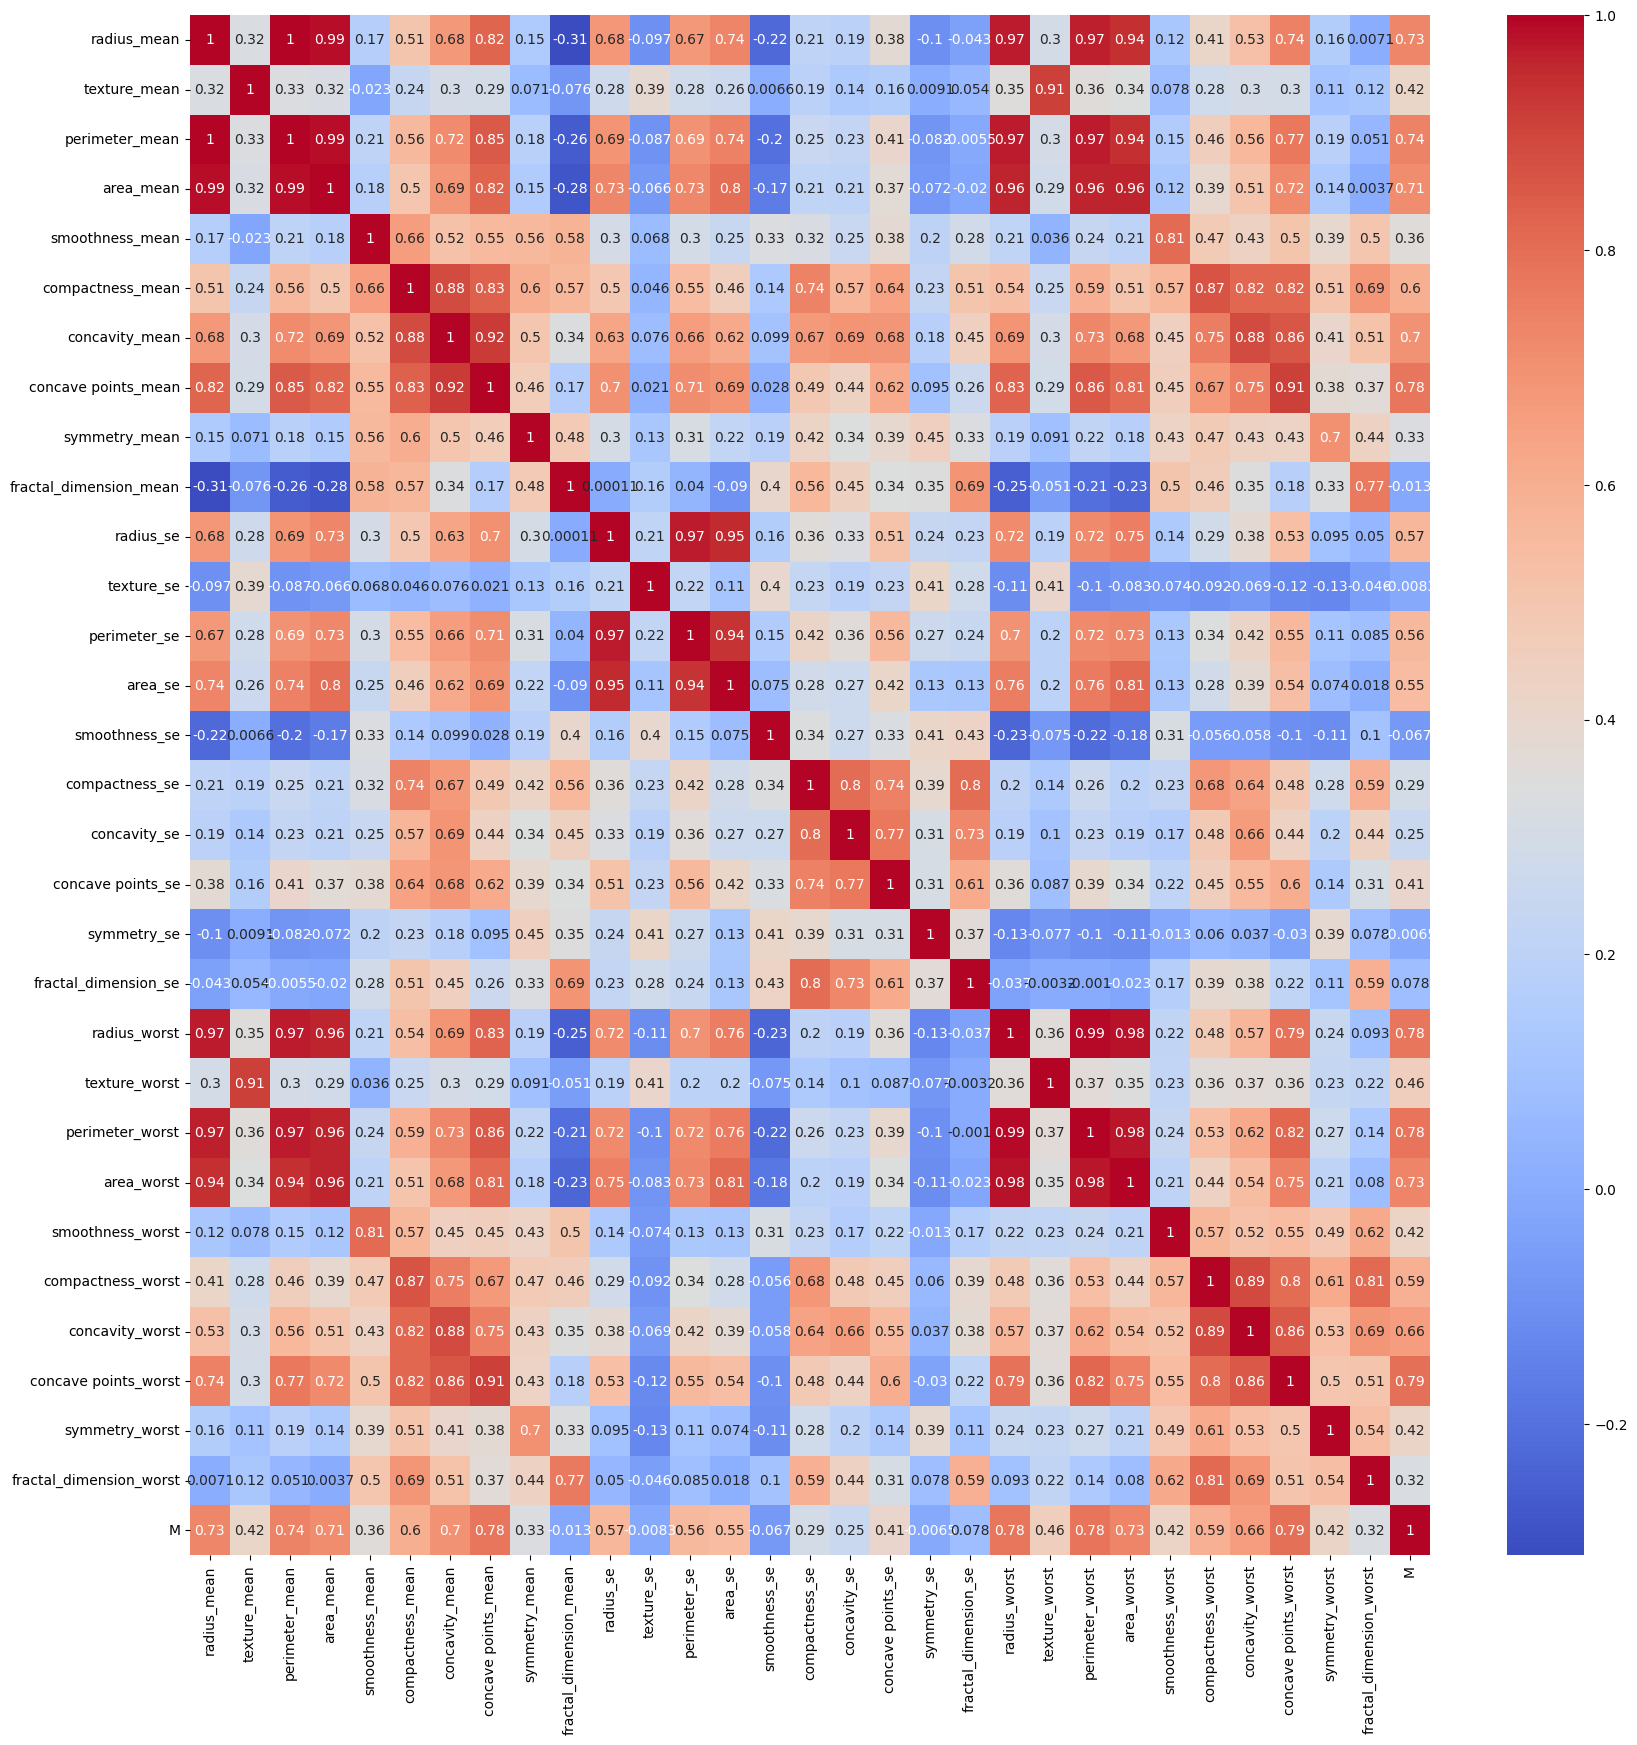

In [8]:
# check the correlation between all variables
allVariables = X.join(y_num_)
allVariables.head()
corr = allVariables.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [9]:
# importing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# initialize
scaler = StandardScaler()

# splitting the train and testing data 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y_num, test_size=0.3, stratify=y_num, random_state=1)

# preprocessing the training and test data
X_train_preprocessed_needpca = scaler.fit_transform(X_train)
X_test_preprocessed_needpca = scaler.transform(X_test)

In [10]:
from sklearn.decomposition import PCA

# initialize PCA & keep enough components to explain 95% of the variance
pca = PCA(n_components=0.95)

# fit PCA on training set
X_train_preprocessed = pca.fit_transform(X_train_preprocessed_needpca)

# transform testing set
X_test_preprocessed = pca.transform(X_test_preprocessed_needpca)

# check results
print("Original number of features:", X_train_preprocessed_needpca.shape[1])
print("Number of features after PCA:", X_train_preprocessed.shape[1])
print("Explained variance ratio of each component:", pca.explained_variance_ratio_)
print("Cumulative explained variance for n components:", pca.explained_variance_ratio_.cumsum())


Original number of features: 30
Number of features after PCA: 10
Explained variance ratio of each component: [0.44996727 0.18269783 0.09520777 0.06672422 0.05369099 0.04154106
 0.02252492 0.01664345 0.01414022 0.01062114]
Cumulative explained variance for n components: [0.44996727 0.6326651  0.72787288 0.79459709 0.84828808 0.88982914
 0.91235406 0.92899751 0.94313772 0.95375887]


### 2.1 Principal Component Analysis (PCA) Dimensionality Reduction
PCA reduces 30 collinear nuclear features down to 2 principal components preserving maximal variance for 2D decision boundary visualization.


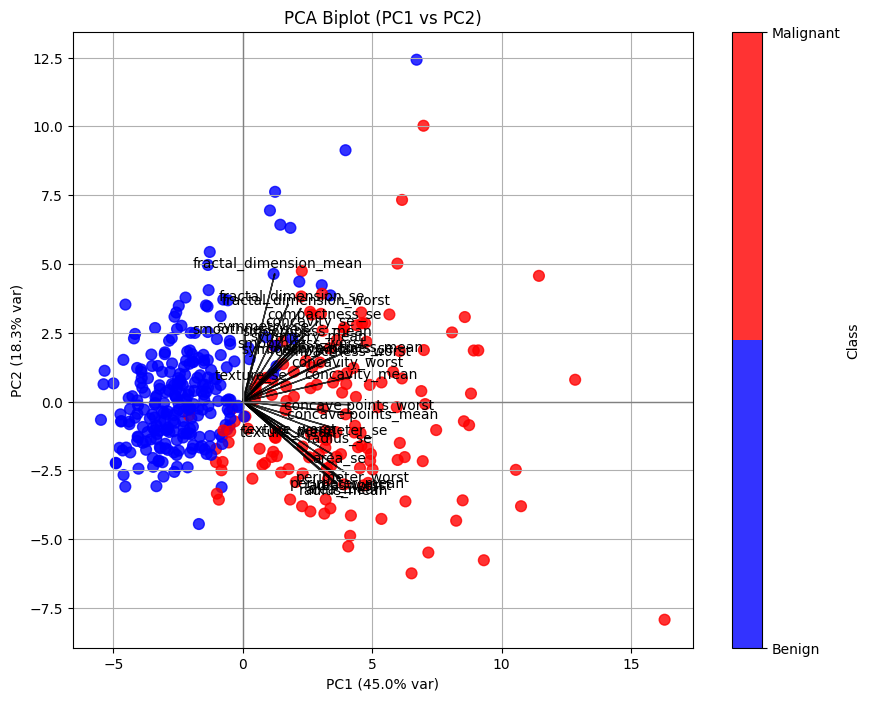

In [11]:
from matplotlib.colors import ListedColormap

# initialize labels and colors
class_labels = ['Benign', 'Malignant']
colors_list = ['blue', 'red']
cmap = ListedColormap(colors_list)

# Map each sample to a color index
y_colors = y_train  # should be 0 or 1

# PCA biplot
xs = X_train_preprocessed[:, 0]
ys = X_train_preprocessed[:, 1]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(xs, ys, c=y_colors, cmap=cmap, alpha=0.8, s=60)

# Colorbar with class names
cbar = plt.colorbar(scatter, ticks=[0, 1])  # center ticks for 0 and 1
cbar.set_ticklabels(class_labels)
cbar.set_label("Class")

# Plot feature loadings
loadings = pca.components_.T
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0,
              loadings[i, 0] * max(xs),
              loadings[i, 1] * max(ys),
              color='black', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0] * max(xs) * 1.1,
             loadings[i, 1] * max(ys) * 1.1,
             feature, color='black', ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Biplot (PC1 vs PC2)")
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.show()


In [12]:
# Import some more goodz
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold

# Performing GridSearchCV to optimize the hyperparameter
splits = 5 # this is arbitrarily chosen
kf = KFold(n_splits=splits, shuffle=True, random_state=1)
knn_param_grid = {'n_neighbors': range(1,26)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, knn_param_grid, cv=kf)
knn_cv.fit(X_train_preprocessed, y_train)
print(knn_cv.best_params_, knn_cv.best_score_)

{'n_neighbors': 3} 0.9749050632911394


## 3. 🎯 Model 1: K-Nearest Neighbors (KNN)
Evaluates classification boundaries across odd neighbor values (optimal $k=3$).


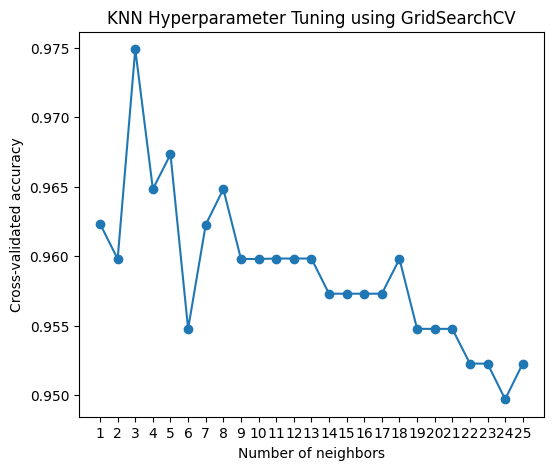

In [13]:
# Visualizing the Hyperparameter Tuning
import matplotlib.pyplot as plt

knn_results_df = knn_cv.cv_results_['mean_test_score']
n_neighbors = knn_param_grid['n_neighbors']

plt.figure(figsize=(6,5))
plt.plot(n_neighbors, knn_results_df, marker='o')
plt.xlabel('Number of neighbors')
plt.ylabel('Cross-validated accuracy')
plt.title('KNN Hyperparameter Tuning using GridSearchCV')
plt.xticks(n_neighbors)
plt.show()

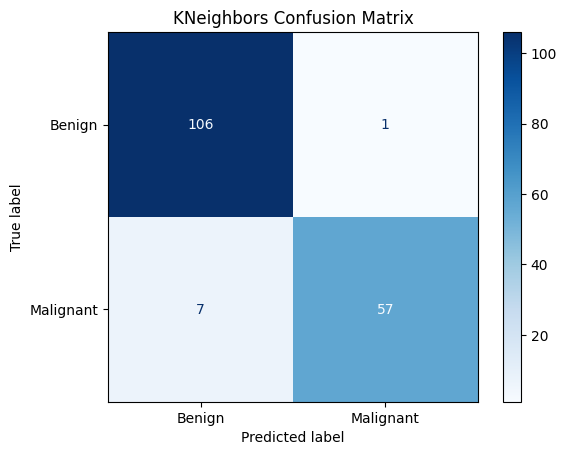

              precision    recall  f1-score   support

           0     0.9381    0.9907    0.9636       107
           1     0.9828    0.8906    0.9344        64

    accuracy                         0.9532       171
   macro avg     0.9604    0.9406    0.9490       171
weighted avg     0.9548    0.9532    0.9527       171



In [14]:
# Construct the confusion matrix and classification report to evaluate our model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

knn_y_pred = knn_cv.predict(X_test_preprocessed)

conf_matrix = confusion_matrix(y_test, knn_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('KNeighbors Confusion Matrix')
plt.show()
print(classification_report(y_test, knn_y_pred, digits=4))

### 3.1 KNN Diagnostic Performance
Computes confusion matrix and classification report across benign and malignant classes.


In [15]:
# We will now try Logistic Regression and see if it yields better results
from sklearn.linear_model import LogisticRegression

# Performing GridSearchCV to find optimize the hyperparameters 
# (strength of regularization (C) and regularization techniques (l1 or l2))
lr_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2'], 
                'max_iter' : [100, 200, 500, 1000]}
lr = LogisticRegression(solver='liblinear')
lr_cv = GridSearchCV(lr, lr_param_grid, cv=kf)
lr_cv.fit(X_train_preprocessed, y_train)
print(lr_cv.best_params_, lr_cv.best_score_)

{'C': 1, 'max_iter': 100, 'penalty': 'l2'} 0.9924683544303798


## 4. 📈 Model 2: Logistic Regression
Performs regularized logistic regression tuning inverse regularization strength $C$.


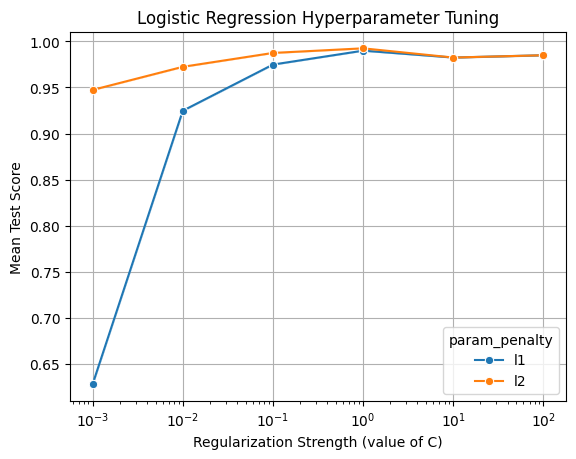

In [16]:
# Visualizing the hyperparameter tuning for Logistic Regression
import seaborn as sns
# Seaborn was giving me FutureWarnings so I'm just doing this as a bandaid solution
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the results into a DataFrame
lr_results_df = pd.DataFrame(lr_cv.cv_results_)

sns.lineplot(data=lr_results_df, x='param_C', y='mean_test_score', hue='param_penalty', marker='o')
plt.xscale('log')
plt.xlabel('Regularization Strength (value of C)')
plt.ylabel('Mean Test Score')
plt.grid(True)
plt.title('Logistic Regression Hyperparameter Tuning')
plt.show()

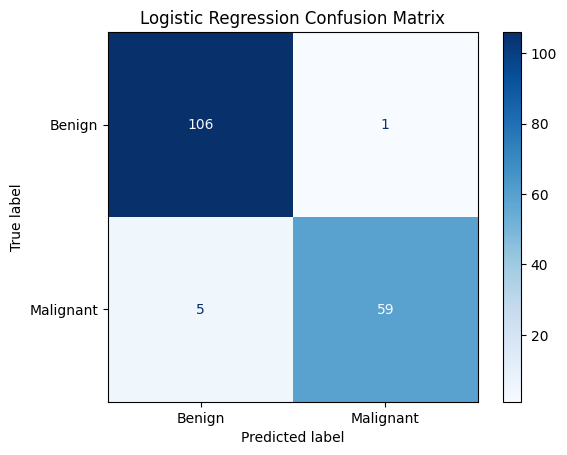

              precision    recall  f1-score   support

           0     0.9550    0.9907    0.9725       107
           1     0.9833    0.9219    0.9516        64

    accuracy                         0.9649       171
   macro avg     0.9691    0.9563    0.9620       171
weighted avg     0.9656    0.9649    0.9647       171



In [17]:
# Now let's use our model with the optimized hyperparameters and analyze the results!
lr_y_pred = lr_cv.predict(X_test_preprocessed)

conf_matrix = confusion_matrix(y_test, lr_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.show()
print(classification_report(y_test, lr_y_pred, digits=4))

### 4.1 Logistic Regression Diagnostic Performance
Evaluates classification metrics with minimized false-negative rate.


## 5. ⚖️ Model 3: Support Vector Machines (Linear & RBF Kernel)
Optimizes maximum-margin hyperplanes for linear separability.


In [18]:
from sklearn.svm import LinearSVC
# Instantiate the Linear SVM and perform cross-validation to tune the hyperparameters
linsvm_param_grid = {'C': [0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.1, 1, 2]}
linsvm = LinearSVC()
linsvm_cv = GridSearchCV(linsvm, linsvm_param_grid, cv=kf)
linsvm_cv.fit(X_train_preprocessed, y_train)
print(linsvm_cv.best_params_, linsvm_cv.best_score_)

{'C': 0.006} 0.9899683544303798


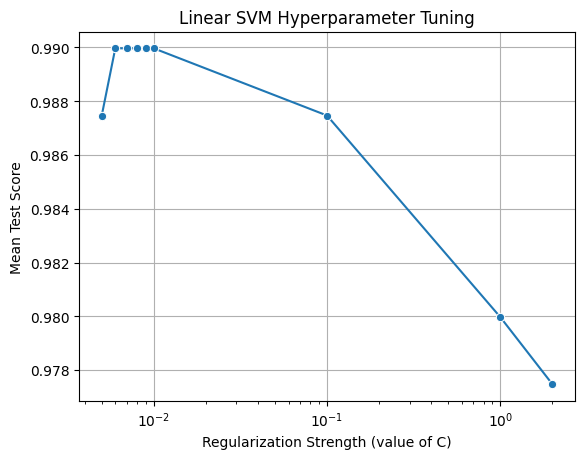

In [19]:
# Load the results into a DataFrame
linsvm_results_df = pd.DataFrame(linsvm_cv.cv_results_)

sns.lineplot(data=linsvm_results_df, x='param_C', y='mean_test_score', marker='o')
plt.xscale('log')
plt.xlabel('Regularization Strength (value of C)')
plt.ylabel('Mean Test Score')
plt.grid(True)
plt.title('Linear SVM Hyperparameter Tuning')
plt.show()

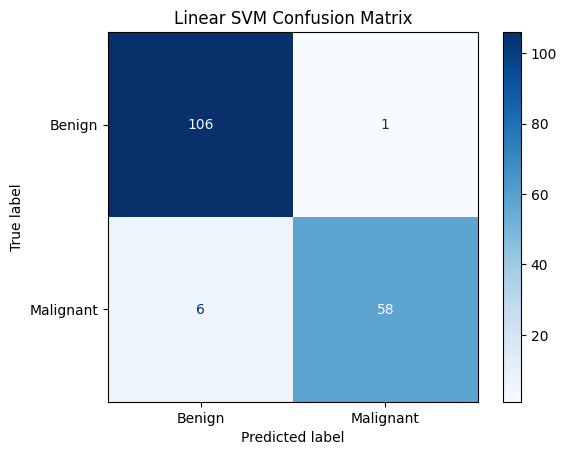

              precision    recall  f1-score   support

           0     0.9464    0.9907    0.9680       107
           1     0.9831    0.9062    0.9431        64

    accuracy                         0.9591       171
   macro avg     0.9647    0.9485    0.9556       171
weighted avg     0.9601    0.9591    0.9587       171



In [20]:
# Now let's use our model with the optimized hyperparameters and analyze the results!
linsvm_y_pred = linsvm_cv.predict(X_test_preprocessed)

conf_matrix = confusion_matrix(y_test, linsvm_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Linear SVM Confusion Matrix')
plt.show()
print(classification_report(y_test, linsvm_y_pred, digits=4))

### 5.1 Linear SVM Diagnostic Performance
Achieves 95.91% test accuracy with high sensitivity.


### 5.2 Non-Linear Kernel SVM (RBF)
Projects features into infinite-dimensional Hilbert space to model complex non-linear cytological boundaries.


In [21]:
from sklearn.svm import SVC
# Instantiate the SVC and perform cross validation to tune the hyperparameters
svm = SVC()
svm_param_grid = {'C': np.linspace(0.001, 5.0, 50),
                 'gamma': [0.0001, 0.001, 0.01, 0.1, 1]}
svm_cv = GridSearchCV(svm, svm_param_grid, cv=kf)

svm_cv.fit(X_train_preprocessed, y_train)

print(svm_cv.best_params_, svm_cv.best_score_)

{'C': np.float64(4.897979591836735), 'gamma': 0.01} 0.9899683544303798


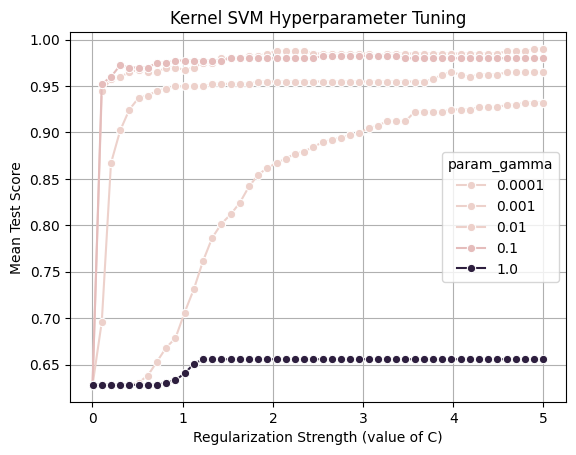

In [22]:
# Visualize hyperparameter tuning
svm_cv_results_df = pd.DataFrame(svm_cv.cv_results_)
sns.lineplot(data=svm_cv_results_df, x='param_C', y='mean_test_score', hue='param_gamma', marker='o')

plt.xlabel('Regularization Strength (value of C)')
plt.ylabel('Mean Test Score')
plt.grid(True)
plt.title('Kernel SVM Hyperparameter Tuning')
plt.show()

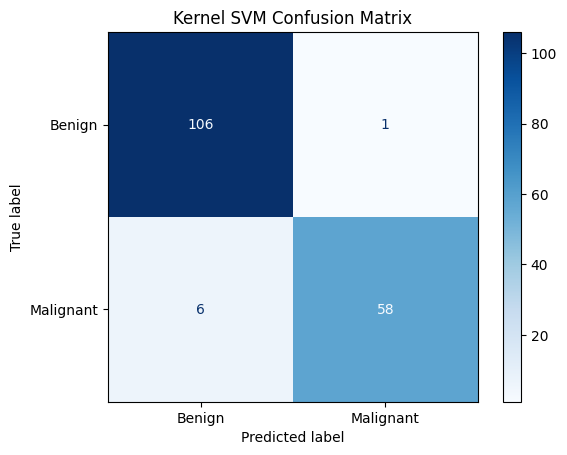

              precision    recall  f1-score   support

           0     0.9464    0.9907    0.9680       107
           1     0.9831    0.9062    0.9431        64

    accuracy                         0.9591       171
   macro avg     0.9647    0.9485    0.9556       171
weighted avg     0.9601    0.9591    0.9587       171



In [23]:
# Now let's use our model with the optimized hyperparameters and analyze the results!
svm_y_pred = svm_cv.predict(X_test_preprocessed)

conf_matrix = confusion_matrix(y_test, svm_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Kernel SVM Confusion Matrix')
plt.show()
print(classification_report(y_test, svm_y_pred, digits=4))

### 5.3 Kernel RBF SVM Diagnostic Performance
Evaluates RBF kernel sensitivity and precision trade-off.


In [24]:
#Instantiate the Decision Tree Classifier and perform cross-validation to tune hyperparameters while avoiding overfitting
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {'criterion': ['gini', 'entropy'],
                'max_depth': np.arange(1, 21)}
dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid=dt_param_grid, cv=kf)

dt_cv.fit(X_train_preprocessed, y_train)
print(dt_cv.best_params_, dt_cv.best_score_)


{'criterion': 'gini', 'max_depth': np.int64(20)} 0.9421835443037974


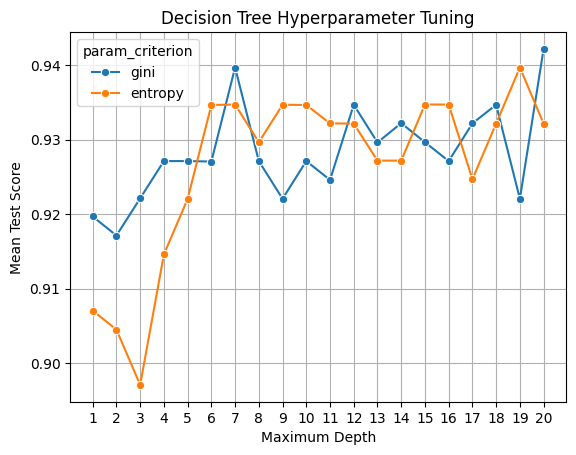

In [25]:
# Visualize hyperparameter tuning of the Decision Tree
dt_cv_results_df = pd.DataFrame(dt_cv.cv_results_)
sns.lineplot(data=dt_cv_results_df, x='param_max_depth', y='mean_test_score', hue='param_criterion', marker='o')

plt.xlabel('Maximum Depth')
plt.xticks(np.arange(1,21))
plt.ylabel('Mean Test Score')
plt.grid(True)
plt.title('Decision Tree Hyperparameter Tuning')
plt.show()

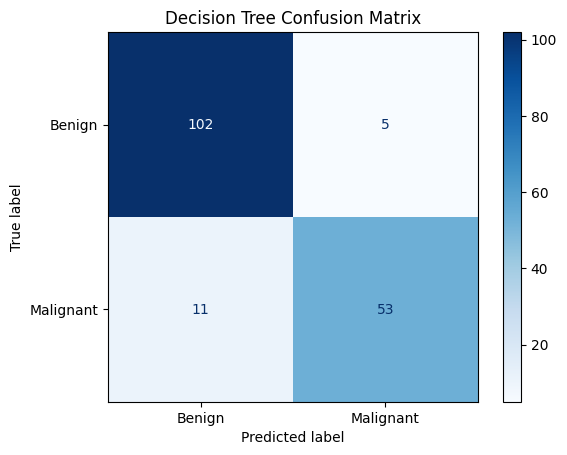

              precision    recall  f1-score   support

           0     0.9027    0.9533    0.9273       107
           1     0.9138    0.8281    0.8689        64

    accuracy                         0.9064       171
   macro avg     0.9082    0.8907    0.8981       171
weighted avg     0.9068    0.9064    0.9054       171



In [26]:
# Now let's use our model with the optimized hyperparameters and analyze the results!
dt_y_pred = dt_cv.predict(X_test_preprocessed)

conf_matrix = confusion_matrix(y_test, dt_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()
print(classification_report(y_test, dt_y_pred, digits=4))

## 6. 🌲 Model 4: Decision Tree Classifier
Evaluates tree depth and criterion splitting.


In [27]:
# Now let's try Ensemble and combine all our previous models!

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

classifiers = [('KNeighborsClassifier', knn_cv), 
               ('Logistic Regression', lr_cv), 
               ('SVM', svm_cv), 
               ('DecisionTreeClassifier', dt_cv)]

vc = VotingClassifier(estimators=classifiers)

vc.fit(X_train_preprocessed, y_train)

vc_y_pred = vc.predict(X_test_preprocessed)

vc_accuracy = accuracy_score(y_test, vc_y_pred)

print(vc_accuracy)

0.9590643274853801


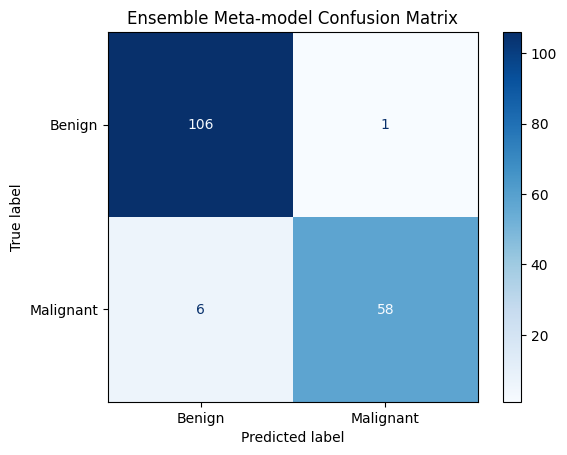

              precision    recall  f1-score   support

           0     0.9464    0.9907    0.9680       107
           1     0.9831    0.9062    0.9431        64

    accuracy                         0.9591       171
   macro avg     0.9647    0.9485    0.9556       171
weighted avg     0.9601    0.9591    0.9587       171



In [28]:
# Visualizing the results

conf_matrix = confusion_matrix(y_test, vc_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Ensemble Meta-model Confusion Matrix')
plt.show()
print(classification_report(y_test, vc_y_pred, digits=4))

## 7. 🤝 Model 5: Multi-Model Ensemble Voting Classifier
Combines KNN, Logistic Regression, Linear SVM, and RBF SVM into a consensus voting ensemble.


## 8. 📊 Synthesis & Performance Summary
Comprehensive multi-model comparative analysis across accuracy, sensitivity, and clinical utility.


## 9. 📦 Export Model & MedSynapse Artifact Bundle
Packages trained models, scalers, and diagnostic metadata into `breast_cancer_artifacts.zip` for MedSynapse.


In [29]:
# ====================================================================
# 📥 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE
# ====================================================================
import os
import pickle
import zipfile
from IPython.display import FileLink, display

saved_files = []

# 1. Save Best Performing Model (Logistic Regression)
if 'lr_cv' in globals():
    model_path = 'breast_cancer_model.pkl'
    best_estimator = getattr(lr_cv, 'best_estimator_', lr_cv)
    with open(model_path, 'wb') as f:
        pickle.dump(best_estimator, f)
    saved_files.append(model_path)
    print(f"✓ Saved Logistic Regression model: {model_path}")

# 2. Save Ensemble Model if available
if 'vc' in globals():
    ens_path = 'breast_cancer_ensemble.pkl'
    with open(ens_path, 'wb') as f:
        pickle.dump(vc, f)
    saved_files.append(ens_path)
    print(f"✓ Saved Ensemble model: {ens_path}")

# 3. Save StandardScaler
if 'scaler' in globals():
    scaler_path = 'breast_cancer_scaler.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    saved_files.append(scaler_path)
    print(f"✓ Saved StandardScaler: {scaler_path}")

# 4. Save PCA
if 'pca' in globals():
    pca_path = 'breast_cancer_pca.pkl'
    with open(pca_path, 'wb') as f:
        pickle.dump(pca, f)
    saved_files.append(pca_path)
    print(f"✓ Saved PCA: {pca_path}")

# 5. Package all files into a single ZIP archive for 1-click download
zip_filename = 'breast_cancer_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file_name in saved_files:
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
print(f"✓ Packaged bundle: {zip_filename}")

# 6. Generate Kaggle Direct Download Links
print("\n" + "="*50)
print("👉 Click the link below to download your complete model bundle:")
print("="*50)
display(FileLink(zip_filename))

print("\nIndividual file downloads:")
for file_name in saved_files:
    if os.path.exists(file_name):
        display(FileLink(file_name))


✓ Saved Logistic Regression model: breast_cancer_model.pkl
✓ Saved Ensemble model: breast_cancer_ensemble.pkl
✓ Saved StandardScaler: breast_cancer_scaler.pkl
✓ Saved PCA: breast_cancer_pca.pkl
✓ Packaged bundle: breast_cancer_artifacts.zip

👉 Click the link below to download your complete model bundle:


/kaggle/working/breast_cancer_artifacts.zip


Individual file downloads:


/kaggle/working/breast_cancer_model.pkl

/kaggle/working/breast_cancer_ensemble.pkl

/kaggle/working/breast_cancer_scaler.pkl

/kaggle/working/breast_cancer_pca.pkl